In [ ]:
!pip install datasets
!pip install torch
!pip install transformers
!pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


Please upload a video file:


Saving adidas-tshirt-video.mp4 to adidas-tshirt-video.mp4
Enter text query: black colour long sleeves

Extracted Frame with Person:


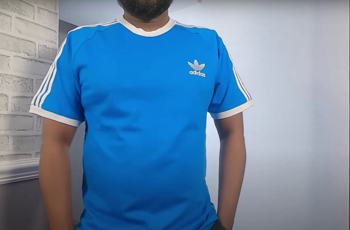


Top 5 Similar Images with the Predicted Brand and Matching Query:

Match 1:
  Name: adidas Men's Essentials Long-Sleeve T-Shirt
  Brand: adidas


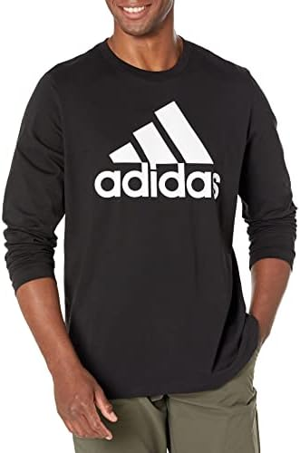


Match 2:
  Name: Nike Mens Pro Warm Long Sleeve Top
  Brand: Nike


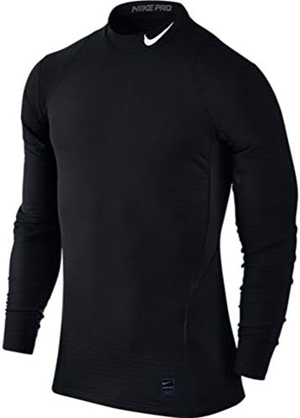


Match 3:
  Name: PUMA Men's BMW M Motorsport Street Midlayer
  Brand: PUMA


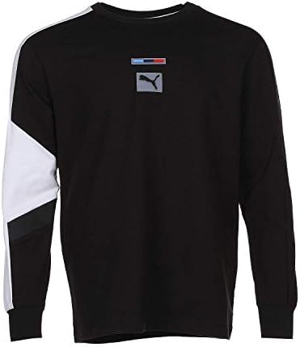


Match 4:
  Name: adidas Men's Long Sleeve Graphic tee
  Brand: adidas


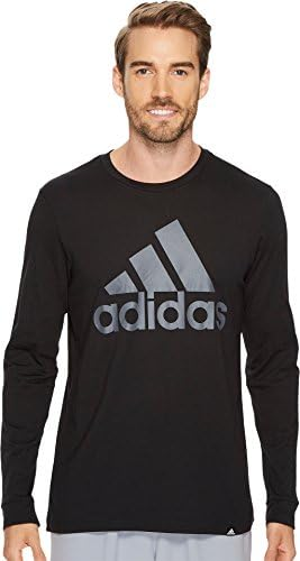


Match 5:
  Name: adidas Men's Long Sleeve Graphic tee
  Brand: adidas


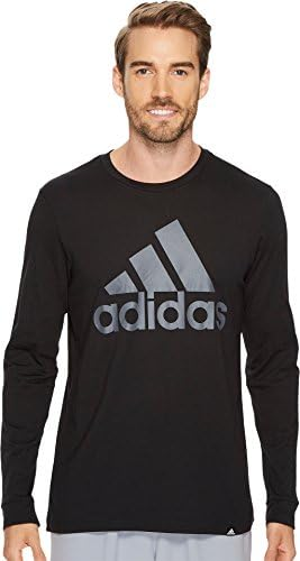

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
from google.colab import files
import requests
from io import BytesIO
import pickle
from IPython.display import display
import cv2
import numpy as np

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()


# Load precomputed embeddings and metadata
pickle_file_path = "/content/drive/My Drive/image_embeddings_amazon_fashion_main.pkl"
with open(pickle_file_path, "rb") as f:
    data = pickle.load(f)

stored_embeddings = data["embeddings"]
stored_metadata = data["metadata"]

# Helper function to fetch image from URL
def fetch_image_from_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Error fetching image from URL {url}: {e}")
        return None

# Helper function to display images with a custom width
def display_image_with_width(image, width):
    aspect_ratio = image.height / image.width
    new_height = int(width * aspect_ratio)
    resized_image = image.resize((width, new_height))
    display(resized_image)

# Step 1: Upload the query video
print("Please upload a video file:")
uploaded = files.upload()
query_video_path = list(uploaded.keys())[0]
# query_video_path = "/content/nike-hoody.mp4"

# Input the accompanying text query
query_text = input("Enter text query: ")

# Detect and extract a frame with the person's image from the video
def extract_person_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    detected_frame = None

    # Use a pre-trained Haar Cascade for person detection
    person_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_fullbody.xml')

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to grayscale for detection
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        persons = person_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=3, minSize=(50, 50))

        if len(persons) > 0:
            # Return the entire frame where the person is detected
            detected_frame = frame
            break

    cap.release()
    return detected_frame

# Extract the frame with a person
detected_frame = extract_person_frame(query_video_path)

if detected_frame is not None:
    # Convert to RGB and display the image
    query_image = Image.fromarray(cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB))
    print("\nExtracted Frame with Person:")
    display_image_with_width(query_image, width=350)
else:
    print("No person detected in the video.")
    exit()

# Step 2: Combine image and text query for similarity
def compute_combined_query_embedding(image, text):
    inputs = processor(text=text, images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        image_embeds = model.get_image_features(pixel_values=inputs["pixel_values"]).squeeze()
        text_embeds = model.get_text_features(input_ids=inputs["input_ids"]).squeeze()
        # Combine image and text embeddings with more weightage on text
        combined_embeds = (0.3 * image_embeds + 0.7 * text_embeds)  # Weighted average
    return combined_embeds.cpu().numpy()

combined_query_embedding = compute_combined_query_embedding(query_image, query_text)

# Compute cosine similarity with stored embeddings
similarities = cosine_similarity([combined_query_embedding], stored_embeddings)[0]

# Sort indices by similarity
sorted_indices = similarities.argsort()[::-1]  # Descending order
Visual-Search-Week4(Video_Query)
# Get the top 5 similar images with the predicted brand
top_indices = sorted_indices[:5]

# Step 3: Display the top 5 similar images
print("\nTop 5 Similar Images with the Predicted Brand and Matching Query:")
for i, index in enumerate(top_indices):
    meta = stored_metadata[index]
    print(f"\nMatch {i+1}:")
    print(f"  Name: {meta['title']}")
    print(f"  Brand: {meta['brand']}")
    image_url = meta['image']
    similar_image = fetch_image_from_url(image_url)
    if similar_image:
        display_image_with_width(similar_image, width=300)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
from google.colab import files
import requests
from io import BytesIO
import pickle
from IPython.display import display
import cv2
import numpy as np

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# Predefined brand names for brand prediction
brands = ["nike", "adidas", "puma", "levis", "jockey", "tommy hilfiger", "louis vuitton", "gucci"]

# Load precomputed embeddings and metadata
pickle_file_path = "/content/drive/My Drive/image_embeddings_amazon_fashion_main.pkl"
with open(pickle_file_path, "rb") as f:
    data = pickle.load(f)

stored_embeddings = data["embeddings"]
stored_metadata = data["metadata"]

# Helper function to fetch image from URL
def fetch_image_from_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Error fetching image from URL {url}: {e}")
        return None

# Helper function to display images with a custom width
def display_image_with_width(image, width):
    aspect_ratio = image.height / image.width
    new_height = int(width * aspect_ratio)
    resized_image = image.resize((width, new_height))
    display(resized_image)

# Step 1: Upload the query video
print("Please upload a video file:")
uploaded = files.upload()
query_video_path = list(uploaded.keys())[0]
# query_video_path = "/content/adidas-tshirt-video.mp4"

# Input the accompanying text query
query_text = input("Enter text query:")

# Detect and extract a frame with the person's image from the video
def extract_person_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    detected_frame = None

    # Use a pre-trained Haar Cascade for person detection
    person_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_fullbody.xml')

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to grayscale for detection
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        persons = person_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=3, minSize=(50, 50))

        if len(persons) > 0:
            # Return the entire frame where the person is detected
            detected_frame = frame
            break

    cap.release()
    return detected_frame

# Extract the frame with a person
detected_frame = extract_person_frame(query_video_path)

if detected_frame is not None:
    # Convert to RGB and display the image
    query_image = Image.fromarray(cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB))
    print("\nExtracted Frame with Person:")
    display_image_with_width(query_image, width=350)
else:
    print("No person detected in the video.")
    exit()

# Step 2: Predict the brand of the detected clothes
# Process the query image with the predefined brand names
inputs = processor(text=brands, images=query_image, return_tensors="pt", padding=True)

# Extract image and text inputs
image_inputs = inputs["pixel_values"]  # For images
text_inputs = inputs["input_ids"]      # For text

# Compute embeddings for the query image and brand names
with torch.no_grad():
    image_embeds = model.get_image_features(pixel_values=image_inputs)
    text_embeds = model.get_text_features(input_ids=text_inputs)

# Convert embeddings to numpy arrays
image_embeds = image_embeds.cpu().numpy()
text_embeds = text_embeds.cpu().numpy()

# Compute similarity to predict the brand
brand_similarities = cosine_similarity(image_embeds, text_embeds)
predicted_brand = brands[brand_similarities.argmax()]

# Display the predicted brand
print(f"\nPredicted Brand: {predicted_brand}")

# Step 3: Combine image and text query for similarity
def compute_combined_query_embedding(image, text):
    inputs = processor(text=text, images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        image_embeds = model.get_image_features(pixel_values=inputs["pixel_values"]).squeeze()
        text_embeds = model.get_text_features(input_ids=inputs["input_ids"]).squeeze()
        # Combine image and text embeddings with more weightage on text
        combined_embeds = (0.3 * image_embeds + 0.7 * text_embeds)  # Weighted average
    return combined_embeds.cpu().numpy()

combined_query_embedding = compute_combined_query_embedding(query_image, query_text)

# Compute cosine similarity with stored embeddings
similarities = cosine_similarity([combined_query_embedding], stored_embeddings)[0]

# Sort indices by similarity
sorted_indices = similarities.argsort()[::-1]  # Descending order

# Filter images with the predicted brand
filtered_indices = [
    index for index in sorted_indices
    if stored_metadata[index]['brand'].lower() == predicted_brand.lower()
]

# Get the top 5 similar images with the predicted brand
top_indices = filtered_indices[:5]

# Step 4: Display the top 5 similar images
print("\nTop 5 Similar Images with the Predicted Brand and Matching Query:")
for i, index in enumerate(top_indices):
    meta = stored_metadata[index]
    print(f"\nMatch {i+1}:")
    print(f"  Name: {meta['title']}")
    image_url = meta['image']
    similar_image = fetch_image_from_url(image_url)
    if similar_image:
        display_image_with_width(similar_image, width=300)